✅ 2D Asset kaydedildi: ../../../assets\44_logistic_2d.png


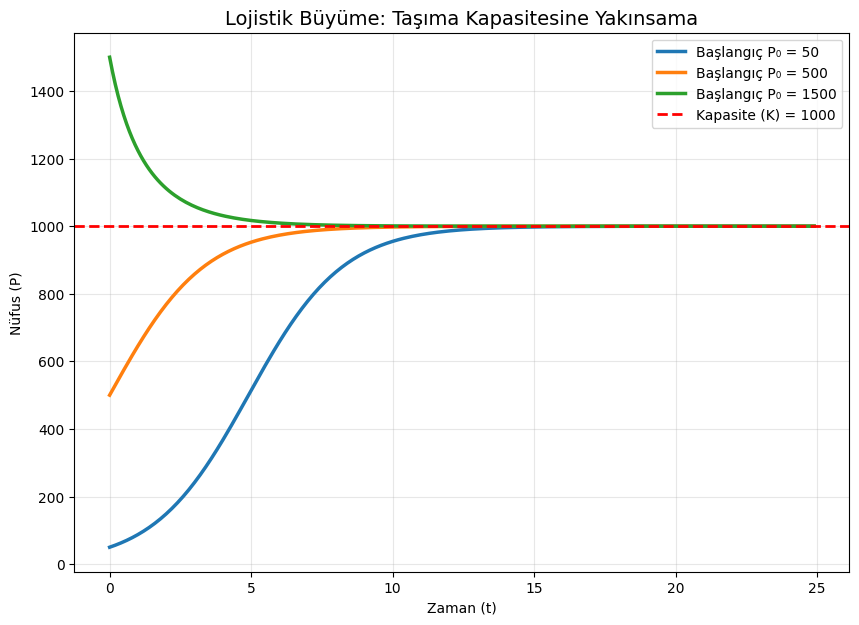

✅ 3D Asset kaydedildi: ../../../assets\44_logistic_3d.png


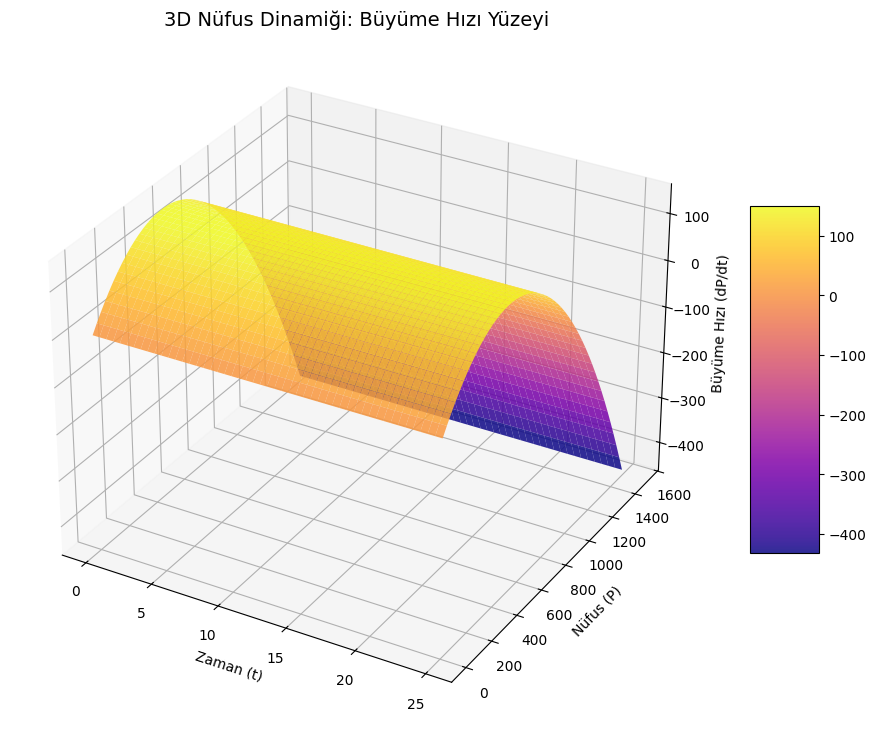

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

def run_logistic_master_v2():
    # --- YOL AYARI ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

      # 1. Model Parametreleri
    r = 0.6    # Büyüme hızı
    K = 1000   # Taşıma kapasitesi (Limit)
    t_end = 25
    dt = 0.1
    t_vals = np.arange(0, t_end, dt)

    def dPdt(P): return r * P * (1 - P / K)

    # Hassas RK4 Çözücü
    def solve_rk4(P0):
        P = np.zeros(len(t_vals))
        P[0] = P0
        for i in range(len(t_vals)-1):
            k1 = dPdt(P[i])
            k2 = dPdt(P[i] + dt*k1/2)
            k3 = dPdt(P[i] + dt*k2/2)
            k4 = dPdt(P[i] + dt*k3)
            P[i+1] = P[i] + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)
        return P

    # --- 📸 ASSET 1: 2D LOGISTIC S-CURVES (SAVE & SHOW) ---
    fig1 = plt.figure(figsize=(10, 7))
    initial_populations = [50, 500, 1500] # Kapasite altı, orta ve üstü
    
    for p0 in initial_populations:
        P_sol = solve_rk4(p0)
        plt.plot(t_vals, P_sol, lw=2.5, label=f'Başlangıç P₀ = {p0}')
    
    plt.axhline(K, color='red', linestyle='--', lw=2, label=f'Kapasite (K) = {K}')
    plt.title("Lojistik Büyüme: Taşıma Kapasitesine Yakınsama", fontsize=14)
    plt.xlabel("Zaman (t)"); plt.ylabel("Nüfus (P)")
    plt.legend(); plt.grid(alpha=0.3)
    
    plt.savefig(os.path.join(asset_path, '44_logistic_2d.png'), dpi=300)
    print(f"✅ 2D Asset kaydedildi: {asset_path}\\44_logistic_2d.png")
    plt.show() # Ekranda göster

    # --- 📸 ASSET 2: 3D GROWTH RATE SURFACE (SAVE & SHOW) ---
    fig2 = plt.figure(figsize=(12, 9))
    ax3d = fig2.add_subplot(111, projection='3d')
    
    P_grid = np.linspace(0, 1500, 50)
    T_grid = np.linspace(0, 25, 50)
    PP, TT = np.meshgrid(P_grid, T_grid)
    ZZ_rate = r * PP * (1 - PP / K) # dP/dt yüzeyi

    surf = ax3d.plot_surface(TT, PP, ZZ_rate, cmap='plasma', alpha=0.85, edgecolor='none')
    
    ax3d.set_title("3D Nüfus Dinamiği: Büyüme Hızı Yüzeyi", fontsize=14)
    ax3d.set_xlabel('Zaman (t)'); ax3d.set_ylabel('Nüfus (P)'); ax3d.set_zlabel('Büyüme Hızı (dP/dt)')
    fig2.colorbar(surf, ax=ax3d, shrink=0.5, aspect=5)
    
    plt.savefig(os.path.join(asset_path, '44_logistic_3d.png'), dpi=300)
    print(f"✅ 3D Asset kaydedildi: {asset_path}\\44_logistic_3d.png")
    plt.show() # Ekranda göster

if __name__ == "__main__":
    run_logistic_master_v2()